# Speech recognition using vector quantizer
#### Team 7
- Words used: acelera, avanza, baja, centra, derecha, desacelera, detente, izquierda, levanta, retrocede  
- Dataset: https://drive.google.com/drive/folders/1O3QLTqvAhBDMlX8ssq5u7D6OaTk5TfT4?usp=sharing

In [28]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.linalg import toeplitz
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

frec_muestreo   = 16000
tam_ventana     = 320
corrimiento     = 128
orden_lpc       = 12
alfa_preenfasis = 0.95
tam_codebook    = 32
n_entrenamiento = 10
n_prueba        = 5

carpeta_audios = 'audios'
palabras = ['acelera','avanza','baja','centra','derecha',
            'desacelera','detente','izquierda','levanta','retrocede']


## Parte 1
Usando el convertidor A/D de una computadora personal, muestrear a 16 kHz 10 palabras diferentes, quince veces cada una de las palabras. (Use palabras que vaya a usar en el contexto del reto de navegación del puzzlebot: start, stop, lift, etc..) 

In [29]:
def cargar_audio(ruta):
    senal, _ = librosa.load(ruta, sr=frec_muestreo, mono=True)
    return senal

grabaciones = {}
for palabra in palabras:
    senales = []
    carpeta = os.path.join(carpeta_audios, palabra)
    archivos = sorted([f for f in os.listdir(carpeta) if f.endswith('.ogg')])
    for archivo in archivos:
        senales.append(cargar_audio(os.path.join(carpeta, archivo)))
    grabaciones[palabra] = senales


## Parte 2
 – Aplique un filtro de preénfasis a cada una de las señales de voz: $H_p(z) = 1 - 0.95\,z^{-1}$

In [30]:
def aplicar_preenfasis(senal, alfa=alfa_preenfasis):
    return lfilter([1, -alfa], [1], senal)

grabaciones_pre = {p: [aplicar_preenfasis(s) for s in grabaciones[p]] for p in palabras}


## Parte 3
Aplique una ventana de Hamming, de 320 puntos, corriéndose cada 128 muestras, a cada una de las señales de voz. 

In [31]:
ventana = np.hamming(tam_ventana)

def entramar(senal):
    tramas = []
    num_tramas = (len(senal) - tam_ventana) // corrimiento + 1
    for i in range(num_tramas):
        inicio = i * corrimiento
        tramas.append(senal[inicio:inicio + tam_ventana] * ventana)
    return tramas



## Parte 4
Detecte el inicio y final de cada palabra. Use, por ejemplo, el cálculo de la potencia de la señal para cada uno de los bloques. Encuentre los umbrales que indican el inicio y final. Puede usarse un enfoque alternativo (manual o a ser discutido en clase, ejemplo: número de cruces por cero)

In [32]:
def recortar_voz(senal, umbral_zcr=0.08, umbral_energia=0.03):
    num_tramas = (len(senal) - tam_ventana) // corrimiento + 1
    energia = np.zeros(num_tramas)
    zcr     = np.zeros(num_tramas)

    for i in range(num_tramas):
        inicio = i * corrimiento
        trama  = senal[inicio:inicio + tam_ventana]
        energia[i] = np.sum(trama**2) / tam_ventana
        zcr[i]     = np.sum(np.abs(np.diff(np.sign(trama)))) / 2 / tam_ventana

    mascara    = (energia > umbral_energia * np.max(energia)) & (zcr > umbral_zcr * np.max(zcr))
    tramas_voz = np.where(mascara)[0]

    if len(tramas_voz) == 0:
        return senal

    muestra_inicio = tramas_voz[0]  * corrimiento
    muestra_fin    = min(tramas_voz[-1] * corrimiento + tam_ventana, len(senal))
    return senal[muestra_inicio:muestra_fin]

grabaciones_recortadas = {p: [recortar_voz(s) for s in grabaciones_pre[p]] for p in palabras}

for palabra in palabras:
    dur = [len(s)/frec_muestreo for s in grabaciones_recortadas[palabra]]
    print(f'  {palabra}: promedio {np.mean(dur):.2f} s  (min {np.min(dur):.2f}, max {np.max(dur):.2f})')


  acelera: promedio 0.62 s  (min 0.24, max 0.82)
  avanza: promedio 0.57 s  (min 0.45, max 0.67)
  baja: promedio 0.43 s  (min 0.40, max 0.48)
  centra: promedio 0.62 s  (min 0.57, max 0.71)
  derecha: promedio 0.52 s  (min 0.43, max 0.65)
  desacelera: promedio 0.93 s  (min 0.57, max 1.12)
  detente: promedio 0.59 s  (min 0.49, max 0.67)
  izquierda: promedio 0.65 s  (min 0.52, max 0.70)
  levanta: promedio 0.64 s  (min 0.55, max 0.78)
  retrocede: promedio 0.77 s  (min 0.61, max 0.87)


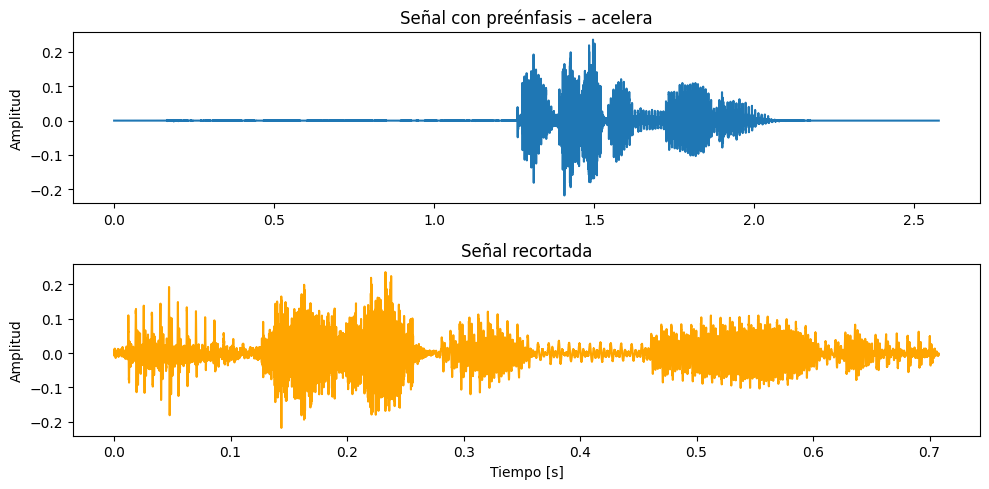

In [33]:
ejemplo   = palabras[0]
sig_orig  = grabaciones_pre[ejemplo][0]
sig_trim  = grabaciones_recortadas[ejemplo][0]

fig, axes = plt.subplots(2, 1, figsize=(10, 5))
t1 = np.arange(len(sig_orig)) / frec_muestreo
t2 = np.arange(len(sig_trim)) / frec_muestreo
axes[0].plot(t1, sig_orig)
axes[0].set_title(f'Señal con preénfasis – {ejemplo}')
axes[0].set_ylabel('Amplitud')
axes[1].plot(t2, sig_trim, color='orange')
axes[1].set_title('Señal recortada')
axes[1].set_xlabel('Tiempo [s]')
axes[1].set_ylabel('Amplitud')
plt.tight_layout()
plt.show()


## Parte 5
Con 10 archivos de cada uno de los números, obtenga sus respectivos cuantizadores vectoriales. Use vectores LPC de orden 12. Para comparar los vectores LPC, hay que emplear la distancia de Itakura-Saito (el clustering o agrupamiento se hace sobre los LSF).  

In [34]:
def autocorrelacion(x, p):
    return np.array([np.dot(x[:len(x)-k], x[k:]) for k in range(p+1)])

def calcular_lpc(trama):
    r = autocorrelacion(trama, orden_lpc)
    if r[0] == 0:
        return np.zeros(orden_lpc)
    R = toeplitz(r[:orden_lpc])
    try:
        a = np.linalg.solve(R, -r[1:orden_lpc+1])
    except np.linalg.LinAlgError:
        a = np.zeros(orden_lpc)
    return a

def lpc_a_lsf(a):
    p      = len(a)
    a_full = np.concatenate(([1], a))
    pol_p  = a_full + np.concatenate((a_full[::-1], [0]))[1:]
    pol_q  = a_full - np.concatenate((a_full[::-1], [0]))[1:]
    rp = np.roots(pol_p)
    rq = np.roots(pol_q)
    rp = rp[np.imag(rp) >= 0]
    rq = rq[np.imag(rq) >= 0]
    lsf = np.sort(np.concatenate((np.angle(rp), np.angle(rq))))
    lsf = lsf[lsf > 0]
    if len(lsf) >= p:
        return lsf[:p]
    return np.pad(lsf, (0, p - len(lsf)), constant_values=np.pi)

def extraer_lsf(senal):
    tramas = entramar(senal)
    return np.array([lpc_a_lsf(calcular_lpc(t)) for t in tramas])



In [35]:
# Cuantización vectorial con LBG
def lbg(vectores, tam, epsilon=0.01, max_iter=100):
    codebook = np.mean(vectores, axis=0, keepdims=True)

    while codebook.shape[0] < tam:
        codebook = np.vstack([codebook * (1 + epsilon), codebook * (1 - epsilon)])
        dist_ant = np.inf
        for _ in range(max_iter):
            dists  = np.linalg.norm(vectores[:, None, :] - codebook[None, :, :], axis=2)
            labels = np.argmin(dists, axis=1)
            nuevo  = np.array([
                vectores[labels == k].mean(axis=0) if np.sum(labels == k) > 0
                else codebook[k]
                for k in range(codebook.shape[0])
            ])
            dist = np.mean(np.min(dists, axis=1))
            if abs(dist_ant - dist) / (dist_ant + 1e-10) < epsilon:
                break
            dist_ant = dist
            codebook = nuevo

    return codebook

codebooks = {}
for palabra in palabras:
    lsf_ent = []
    for senal in grabaciones_recortadas[palabra][:n_entrenamiento]:
        vecs = extraer_lsf(senal)
        if vecs.shape[0] > 0:
            lsf_ent.append(vecs)
    lsf_ent = np.vstack(lsf_ent)
    codebooks[palabra] = lbg(lsf_ent, tam_codebook)
    print(f'{palabra}: {lsf_ent.shape[0]} vectores → codebook {codebooks[palabra].shape}')


/tmp/ipykernel_19686/3398506793.py:17: RuntimeWarning: invalid value encountered in scalar divide
  if abs(dist_ant - dist) / (dist_ant + 1e-10) < epsilon:


acelera: 864 vectores → codebook (32, 12)
avanza: 700 vectores → codebook (32, 12)
baja: 530 vectores → codebook (32, 12)
centra: 760 vectores → codebook (32, 12)
derecha: 623 vectores → codebook (32, 12)
desacelera: 1204 vectores → codebook (32, 12)
detente: 751 vectores → codebook (32, 12)
izquierda: 799 vectores → codebook (32, 12)
levanta: 803 vectores → codebook (32, 12)
retrocede: 954 vectores → codebook (32, 12)


## Parte 6
Usando los 5 archivos restantes de cada número, encuentre la matriz de confusión de reconocimiento empleando los cuantizadores vectoriales que se encontraron en (5). 

In [36]:
# Distancia Itakura-Saito
def dist_itakura(v1, v2):
    return np.sum((v1 - v2)**2)

def clasificar(senal, codebooks):
    vectores = extraer_lsf(senal)
    mejor_palabra = None
    mejor_dist    = np.inf
    for palabra, cb in codebooks.items():
        dist_prom = sum(np.min([dist_itakura(v, cv) for cv in cb]) for v in vectores) / max(len(vectores), 1)
        if dist_prom < mejor_dist:
            mejor_dist    = dist_prom
            mejor_palabra = palabra
    return mejor_palabra

reales    = []
predichos = []
for palabra in palabras:
    for senal in grabaciones_recortadas[palabra][n_entrenamiento:n_entrenamiento + n_prueba]:
        pred = clasificar(senal, codebooks)
        reales.append(palabra)
        predichos.append(pred)
        print(f'  Real: {palabra:12s}  Predicho: {pred}')

print(f'\nTotal evaluados: {len(reales)}')


  Real: acelera       Predicho: acelera
  Real: acelera       Predicho: acelera
  Real: acelera       Predicho: acelera
  Real: acelera       Predicho: acelera
  Real: acelera       Predicho: acelera
  Real: avanza        Predicho: avanza
  Real: avanza        Predicho: avanza
  Real: avanza        Predicho: avanza
  Real: avanza        Predicho: avanza
  Real: avanza        Predicho: avanza
  Real: baja          Predicho: baja
  Real: baja          Predicho: baja
  Real: baja          Predicho: baja
  Real: baja          Predicho: baja
  Real: baja          Predicho: baja
  Real: centra        Predicho: centra
  Real: centra        Predicho: centra
  Real: centra        Predicho: centra
  Real: centra        Predicho: centra
  Real: centra        Predicho: centra
  Real: derecha       Predicho: derecha
  Real: derecha       Predicho: derecha
  Real: derecha       Predicho: derecha
  Real: derecha       Predicho: derecha
  Real: derecha       Predicho: derecha
  Real: desacelera    Pre

In [ ]:
def entrenar_codebooks(tam):
    cbs = {}
    for palabra in palabras:
        lsf_ent = []
        for senal in grabaciones_recortadas[palabra][:n_entrenamiento]:
            vecs = extraer_lsf(senal)
            if vecs.shape[0] > 0:
                lsf_ent.append(vecs)
        cbs[palabra] = lbg(np.vstack(lsf_ent), tam)
    return cbs

def evaluar(cbs):
    yt, yp = [], []
    for palabra in palabras:
        for senal in grabaciones_recortadas[palabra][n_entrenamiento:n_entrenamiento + n_prueba]:
            yt.append(palabra)
            yp.append(clasificar(senal, cbs))
    return yt, yp

cd_size   = [16, 32, 64]
resultados = {}
for tam in cd_size:
    print(f'Entrenando codebooks de tamaño {tam}...')
    cbs = entrenar_codebooks(tam)
    yt, yp = evaluar(cbs)
    resultados[tam] = (yt, yp)
    acc = np.mean([a == b for a, b in zip(yt, yp)])
    print(f'  Accuracy: {acc*100:.1f}%')

print('\nListo.')


Entrenando codebooks de tamaño 16...


/tmp/ipykernel_19686/3398506793.py:17: RuntimeWarning: invalid value encountered in scalar divide
  if abs(dist_ant - dist) / (dist_ant + 1e-10) < epsilon:


  Accuracy: 100.0%
Entrenando codebooks de tamaño 32...
  Accuracy: 100.0%
Entrenando codebooks de tamaño 64...
  Accuracy: 100.0%

Listo.


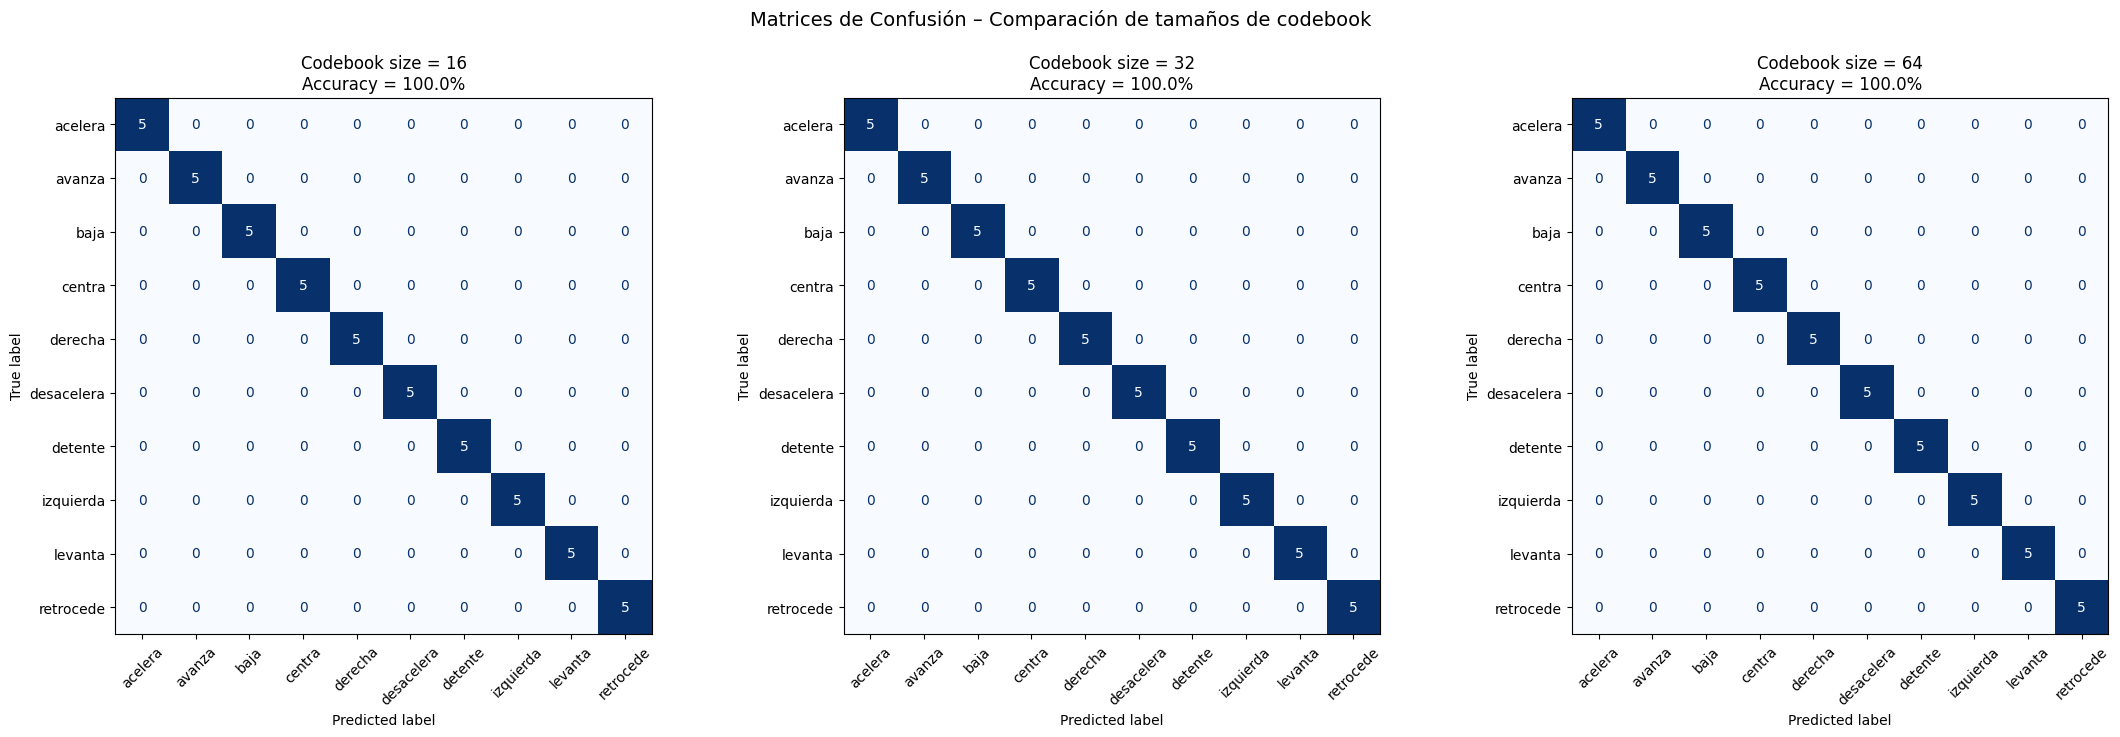

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, tam in zip(axes, cd_size):
    yt, yp = resultados[tam]
    mc  = confusion_matrix(yt, yp, labels=palabras)
    acc = np.trace(mc) / np.sum(mc)
    disp = ConfusionMatrixDisplay(confusion_matrix=mc, display_labels=palabras)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'Codebook size = {tam}\nAccuracy = {acc*100:.1f}%')

plt.suptitle('Matrices de Confusión – Comparación de tamaños de codebook', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
